# **Resume Category Predictor Model**
### By - Tamanna Arora (23csu309)


# 📌 Introduction 

In this project, we aim to analyze and classify resumes based on their content.

##### The main objective is to understand patterns in the resume dataset and prepare it for further machine-learning-based classification.

# ⭐ Purpose

● To automatically analyze and categorize resumes into correct job domains.

● To reduce manual effort and speed up the hiring and screening process.

● To use NLP + Machine Learning for efficient resume understanding.

● To improve accuracy, consistency, and fairness in candidate shortlisting.

● To demonstrate a real-world AIML application in HR automation.

-------------------------------------------------------------------------------

🡆 The dataset used is "UpdatedResumeDataSet.csv", which contains resumes along with their assigned categories. It includes text data from various domains such as Data Science, HR, Java Developer, and more.

# 🎯 Scope

● Understanding the dataset structure

● Cleaning and preprocessing text

● Analyzing resume categories

● Visualizing patterns and trends

# 🛠️ Methods / Approach

## 1. Importing essential libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

 🡆 The CSV file was imported using pandas.

In [13]:
df = pd.read_csv('UpdatedResumeDataSet.csv')

## 3. Data Exploration

 🡆 df.head() is used to inspect the top rows.

In [16]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


 🡆 df.shape is used to check number of rows and columns in the dataset

In [19]:
df.shape

(962, 2)

 🡆 Counted how many times each unique value appears in the Category column

In [22]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

## 4. Visualization Approach

🡆 Print unique values of Category column

In [26]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

#### Pie Chart

🡆 The pie chart visualizes the proportion of resumes belonging to each job category.

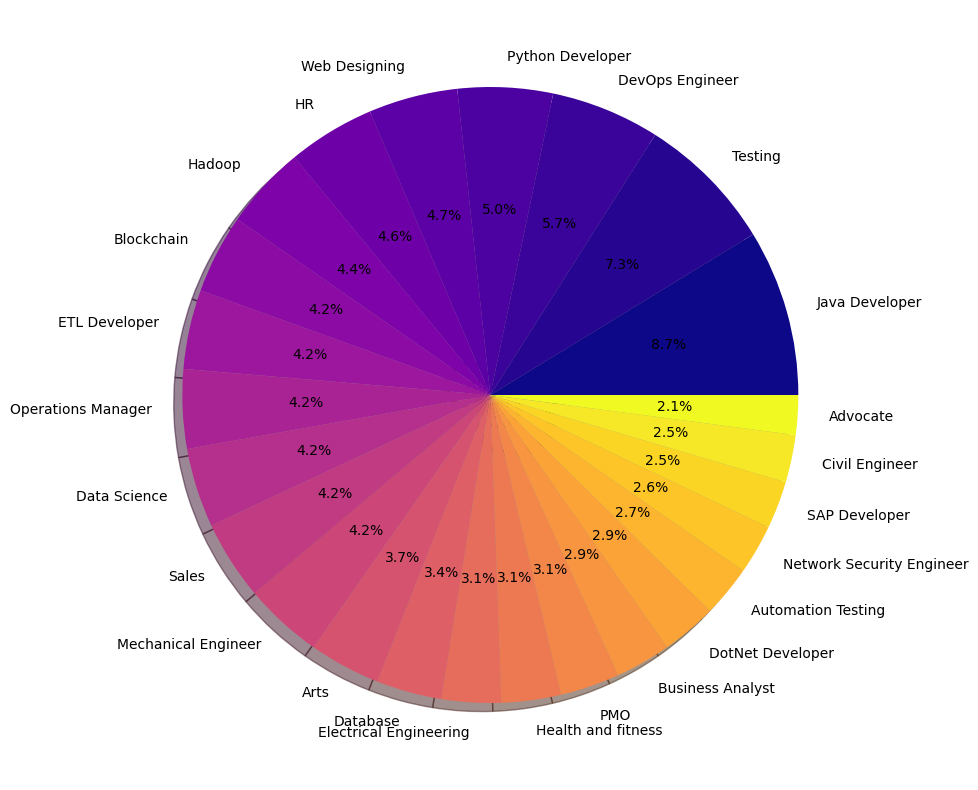

In [29]:
counts = df['Category'].value_counts()
plt.figure(figsize=(15,10))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    shadow=True,
    colors=plt.cm.plasma(np.linspace(0,1,len(counts)))
)

plt.show()

#### Assumptions of pie chart
● It helps us understand how resumes are distributed across different fields and highlights which categories have the highest or lowest representation.

● Each slice represents a category, and the percentage shows its contribution to the overall dataset.

-------------------------------------------------------------------------------------

🡆 Shows the job category of the first resume

In [33]:
df['Category'][0]

'Data Science'

🡆 Shows the full resume text corresponding to that category

In [36]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

## 5. Oversampling Code 

In [39]:
# Checking Original Category Distribution
print("Original Category Distribution:")
print(df['Category'].value_counts())

# Get the largest category size (i.e., the category with the maximum number of entries)
max_size = df['Category'].value_counts().max()

# Perform oversampling
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# Shuffle the dataset to avoid any order bias
df = balanced_df.sample(frac=1).reset_index(drop=True)

# Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
Blockchain                   84
Operations Manager           84
SAP De

C:\Users\Tamanna Arora\AppData\Local\Temp\ipykernel_22788\512433673.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)


#### Result

● Each category has at least one entry, so oversampling can repeat samples to match the largest class.

● Duplicating samples is acceptable at this stage.

● Noise, inconsistent formatting, or special characters in the resume text do not affect oversampling.

● Oversampling will not remove or edit any data; it only increases minority class samples by duplication.

## 6. cleanResume Function

🡆 The cleanResume() function cleans raw resume text by removing unnecessary elements that do not contribute to meaningful analysis.

In [43]:
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)  
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) 
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Tamanna Arora\AppData\Local\Temp\ipykernel_22788\3739445999.py:3: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
C:\Users\Tamanna Arora\AppData\Local\Temp\ipykernel_22788\3739445999.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
C:\Users\Tamanna Arora\AppData\Local\Temp\ipykernel_22788\3739445999.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', '  ', cleanText)
C:\Use

#### Result

🡆 After applying this function, the resume text becomes more structured, consistent, and machine-readable, making it suitable for feature extraction and NLP modeling.

🡆 Test on a sample text to show how unwanted characters, URLs, and symbols are removed.

In [47]:
cleanResume("my #### $ #  #tamanna webiste like is this http://heloword, hello! @gmain.com")

'my webiste like is this hello '

🡆 Applies the cleaning function to every resume in the dataset.

In [50]:
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

🡆 Displays the cleaned text of the first resume so we can verify that the preprocessing worked correctly.

In [53]:
df['Resume'][0]

'SOFTWARE SKILLS Languages C C java Operating Systems Windows XP 7 Ubuntu RDBMS Oracle SQL Database My SQL PostgreSQL Markup Scripting HTML JavaScript PHP CSS JQuery Angular js Framework Struts Hibernate spring MVC Web Server Tomcat and Glassfish Web Services REST AND SOAP TRAINING DETAIL Duration 4 months From United Telecommunication Limited Jharnet project Place Ranchi Jharkhand Networking Requirements Elementary configuration of router and switch IP and MAC addressing Lease Line OSI Layers Routing protocols Status Network Designer Education Details 2 High School Diploma Government Women Ranchi Jharkhand The Institution Blockchain Engineer Blockchain Engineer Auxledger Skill Details JAVA Exprience 19 months CSS Exprience 12 months HTML Exprience 12 months JAVASCRIPT Exprience 12 months C Exprience 6 monthsCompany Details company Auxledger description Worked with on lots of product on blockchain Bitcoin Build Wallet and explorer on Bitcoin Ethereum Build Wallet and explorer on ethere

## 7. Label Encoding

In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

#### Converts text categories into numeric labels so the model can process them.

In [59]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [61]:
df.Category.unique()

array([ 3, 11, 23, 19,  9,  0, 17, 22,  5,  4, 16, 13, 10, 18, 15, 12,  1,
        7,  8,  6, 20,  2, 24, 21, 14])

## 8. Vectorization

#### Transforms cleaned resume text into numerical TF-IDF features for machine learning.

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume'])
requredTaxt  = tfidf.transform(df['Resume'])
print(requredTaxt)

  (0, 34)	0.07456933808287895
  (0, 60)	0.034173141728665625
  (0, 96)	0.02429778244142346
  (0, 97)	0.02140589484258023
  (0, 98)	0.019412837697966256
  (0, 99)	0.017466434482220673
  (0, 316)	0.05001822917103423
  (0, 317)	0.05001822917103423
  (0, 330)	0.03173520700387907
  (0, 501)	0.031539410629583854
  (0, 532)	0.08379701004478926
  (0, 542)	0.05067704226528448
  (0, 692)	0.058782185898988856
  (0, 727)	0.10003645834206847
  (0, 764)	0.03382638480635758
  (0, 787)	0.038048690832596106
  (0, 808)	0.02862978866345872
  (0, 895)	0.04519358151736203
  (0, 896)	0.09495432015212021
  (0, 900)	0.1747059631013708
  (0, 910)	0.041282699188455584
  (0, 912)	0.3851165194811274
  (0, 1021)	0.1277450256814325
  (0, 1025)	0.050481572245967214
  (0, 1042)	0.05001822917103423
  :	:
  (2099, 4289)	0.1173969889034984
  (2099, 4303)	0.1573910978782526
  (2099, 4322)	0.04853637483686479
  (2099, 4344)	0.11210998520928918
  (2099, 4586)	0.05304358360766579
  (2099, 4613)	0.06290218833017663
  (2099, 

## 9. Train-Test Split

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(requredTaxt, df['Category'], test_size=0.2, random_state=42)

#### Checking shapes (rows & columns)

In [70]:
X_train.shape

(1680, 7351)

In [75]:
X_test.shape

(420, 7351)

In [77]:
print(X_train)

  (0, 98)	0.029301092213912694
  (0, 256)	0.03539593760781074
  (0, 257)	0.048512841408260815
  (0, 289)	0.0481010214472112
  (0, 297)	0.04648741288978123
  (0, 483)	0.029599319899057706
  (0, 491)	0.036921343311856564
  (0, 525)	0.09027491211700077
  (0, 542)	0.050993495872717017
  (0, 719)	0.13640869571236602
  (0, 809)	0.052053805470992316
  (0, 832)	0.06872638943468248
  (0, 907)	0.1898696502130219
  (0, 927)	0.06444644924489934
  (0, 953)	0.26716140769498864
  (0, 1021)	0.03856281946613537
  (0, 1117)	0.04056220835245365
  (0, 1118)	0.03584587408837541
  (0, 1186)	0.049379349342806154
  (0, 1330)	0.03949721612565791
  (0, 1361)	0.047555761939225914
  (0, 1399)	0.030414527822922793
  (0, 1408)	0.0502375341608571
  (0, 1416)	0.06872638943468248
  (0, 1434)	0.03743057726241294
  :	:
  (1679, 6436)	0.028311881243307396
  (1679, 6557)	0.059369006278949955
  (1679, 6559)	0.0375263988984111
  (1679, 6563)	0.06775982158974733
  (1679, 6569)	0.05163955388315536
  (1679, 6609)	0.06372455058

## 10. K-Nearest Neighbors (KNN) Classifier

🡆 This code trains a K-Nearest Neighbors (KNN) classifier using a One-Vs-Rest strategy to handle multiple categories.

🡆 Since TF-IDF vectors are sparse, the code first converts them into dense arrays.

🡆 The model is then trained on the training data, and predictions are made on the test set.

🡆 Finally, it prints key evaluation metrics including accuracy, the confusion matrix, and the classification report.

In [75]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure that X_train and X_test are dense if they are sparse
X_train = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# 1. Train KNeighborsClassifier
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 0.9976
Confusion Matrix:
[[17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   1]
 [ 0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  

#### Result

● Accuracy = 1 [(correct predictions) / (total predictions)] shows KNN model classified resumes correctly.

● Confusion Matrix shows category-wise misclassifications.

● Classification Report provides precision, recall, and F1-score for each resume category.

## 11. Support Vector Classifier (SVC)

🡆 This code trains a Support Vector Classifier (SVC) using a One-Vs-Rest approach for multi-class classification.

🡆 The model learns decision boundaries between categories using the TF-IDF features.

🡆 After training, it predicts categories for the test set and prints essential evaluation metrics: accuracy, confusion matrix, and classification report.

In [125]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ✅ Use linear kernel (much faster for text)
svc_model = OneVsRestClassifier(SVC(kernel='linear'))

# ✅ Train the model
print("Training started...")
svc_model.fit(X_train, y_train)
print("✅ Training complete!")

# ✅ Predict on test data
y_pred_svc = svc_model.predict(X_test)

# ✅ Display results
print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")

Training started...
✅ Training complete!

SVC Results:
Accuracy: 1.0000
Confusion Matrix:
[[17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  

####
**Result**

● Accuracy shows how well SVC classifies resumes overall.

● Confusion Matrix highlights which categories SVC predicts correctly vs. incorrectly.

● Classification Report provides precision, recall, and F1-score per category to evaluate performance more deeply.

## 12. Random Forest Classifier

🡆 Trained a RandomForestClassifier for a multi-label classification problem using OneVsRestClassifier, which means:

     🡆 A separate Random Forest model is trained for each label.

     🡆 For every test sample, the model predicts multiple possible classes.

     🡆 Random Forest improves performance by combining results of many decision trees.

In [81]:
rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


RandomForestClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 23  0  0  0  0  0

#### Result
#### HERE PRECISION=1 tells us model never predicted a class as positive incorrectly .

#### RECALL=1 tells us model found all the actual positives.

#### F1 SCORE =1 since both above are perfect F1 is also correct

● Accuracy: The printed score tells how often the model predicts all labels correctly for each sample. 

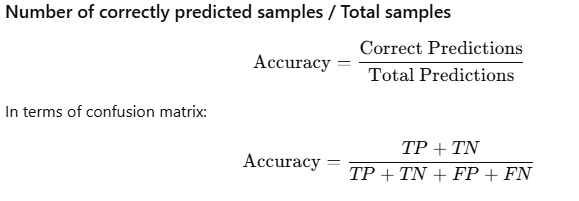

● Confusion Matrix: Shows correct vs incorrect predictions for each label—helps identify where the model is misclassifying.

● Classification Report gives: 

    ● Precision → how many predicted labels were correct! 
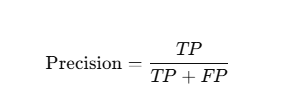

    ● Recall → how many actual labels the model detected 
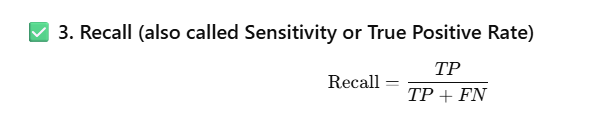

    ● F1-Score → balance of precision and recall  
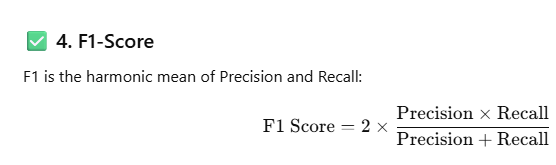

## 13. Saving trained dataset

🡆 Used pickle to save three important objects:

      🡆 tfidf.pkl → your trained TF-IDF vectorizer

      🡆 clf.pkl → your trained SVM (svc_model) classifier

      🡆 encoder.pkl → your label encoder

In [84]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(svc_model, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

##### 🡆 The pred() function cleans the input resume, vectorizes it using the saved TF-IDF model, predicts its job category with the trained SVC classifier, and returns the decoded category name.

In [86]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = cleanResume(input_resume) 

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svc_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name

##### 🡆 The model confidently predicted the resume as Health & Fitness, as it strongly emphasizes personal training, exercise science, and wellness coaching.

In [88]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Health and Fitness-focused resume
pred(myresume)

'Health and fitness'

##### 🡆 The model predicted this resume as Cyber Security due to the strong presence of network protection, penetration testing, and major cybersecurity certifications.

In [90]:
myresume = """
John Doe is an experienced Network Security Engineer with over 7 years of expertise in designing, implementing, and managing network security infrastructures. Specializing in safeguarding critical network systems, John has worked with various organizations to protect against cyber threats, data breaches, and unauthorized access. He is proficient in deploying firewalls, intrusion detection systems (IDS), VPNs, and network monitoring tools to ensure the integrity and security of networks.

John holds a degree in Computer Science and certifications in several cybersecurity domains, including Certified Information Systems Security Professional (CISSP), Certified Ethical Hacker (CEH), and Cisco Certified Network Associate (CCNA). He has extensive experience in troubleshooting and resolving network vulnerabilities, and has played a key role in conducting security audits and risk assessments.

Key Skills:
- Network Security Architecture
- Firewall Management and Configuration
- Intrusion Detection and Prevention Systems (IDS/IPS)
- Virtual Private Networks (VPNs)
- Security Audits and Risk Assessments
- Cybersecurity Incident Response
- Network Monitoring and Traffic Analysis
- Vulnerability Assessment and Penetration Testing
- Data Encryption and Secure Communications

Certifications:
- CISSP (Certified Information Systems Security Professional)
- CEH (Certified Ethical Hacker)
- CCNA (Cisco Certified Network Associate)
- CompTIA Security+

Education:
BSc in Computer Science, XYZ University, 2012-2016

Professional Experience:
- Network Security Engineer at ABC Corp (2016-Present)
- IT Security Specialist at DEF Solutions (2014-2016)

Languages:
- English (Fluent)
- French (Intermediate)
"""

# Now, test the model with the Network Security Engineer-focused resume
pred(myresume)


'Network Security Engineer'

##### 🡆 The model predicted this resume as Legal / Advocate due to strong keywords related to law practice, litigation, legal research, and courtroom advocacy.

In [92]:
myresume = """
Sarah Williams is a dedicated and skilled advocate with over 10 years of experience in providing legal representation to clients across various sectors, including criminal law, civil litigation, and family law. With a deep understanding of legal procedures and case law, Sarah has successfully handled numerous cases in the courtroom, negotiating favorable settlements and providing expert legal advice to individuals and businesses.

She holds a law degree from XYZ University and is a licensed attorney, practicing law in multiple jurisdictions. Sarah is passionate about ensuring justice is served and strives to make legal processes more accessible to her clients. She is known for her excellent research and analytical skills, attention to detail, and commitment to upholding the law with integrity.

Key Skills:
- Criminal Law
- Civil Litigation
- Family Law
- Contract Law
- Legal Research and Writing
- Courtroom Advocacy
- Legal Counseling and Advice
- Client Relationship Management
- Legal Compliance and Regulations
- Negotiation and Settlement

Certifications and Licenses:
- Licensed Attorney at Law, XYZ State Bar
- Certification in Criminal Law, XYZ University

Education:
JD in Law, XYZ University, 2010-2013

Professional Experience:
- Senior Advocate at ABC Law Firm (2016-Present)
- Associate Advocate at DEF Legal Group (2013-2016)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Advocate-focused resume
pred(myresume)


'Advocate'

🡆 This function takes a PDF file as input, extracts the text, converts it into TF-IDF features using the trained vectorizer, and then predicts the resume’s category using the trained classification model.

In [94]:
import pickle

with open("tfidf.pkl", "rb") as f:
    tfidf = pickle.load(f)

with open("clf.pkl", "rb") as f:
    clf = pickle.load(f)

with open("encoder.pkl", "rb") as f:
    encoder = pickle.load(f)


In [95]:
def predict_resume_category(pdf_path):
    text = extract_text_from_pdf(pdf_path)

    vector = tfidf.transform([text]).toarray()
    prediction = clf.predict(vector)
    category = encoder.inverse_transform(prediction)[0]

    return category


🡆 This line runs the prediction function on the resume stored in specific pdf's and outputs the job category assigned by the trained model.

In [97]:
def extract_text_from_pdf(pdf_path):
    import PyPDF2
    text = ""
    with open(pdf_path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            text += page.extract_text() or ""
    return text


In [98]:
predict_resume_category("Tanvi.pdf")


'Data Science'

In [99]:
predict_resume_category("Resume 0125.pdf")

'HR'

In [100]:
predict_resume_category("Resume_format_from_NCU[1].pdf")

'Data Science'

# **REFERENCES**
**Source 1 Dataset**  https://www.kaggle.com/datasets/gauravduttakiit/resume-dataset

**Scikit Lib used in python** https://www.geeksforgeeks.org/machine-learning/learning-model-building-scikit-learn-python-machine-learning-library/

**Streamlit** https://streamlit.io/